# 5. Efek Lebaran: apakah modal mie ayam naik menjelang Lebaran?

Pertanyaan notebook ini: apakah biaya bahan mie ayam naik menjelang Lebaran, dan kalau iya seberapa besar?

**Bagian 1 (hari ini):** siapkan data biaya per porsi dan tandai bulan Lebaran.
**Bagian 2 (berikutnya):** bandingkan sebelum, saat, dan sesudah Lebaran.

## Langkah 1: Muat data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/kaggle/input/datasets/samuelgeraldo/bedah-mie-ayam-pakai-data-bukan-sumpit/harga_pangan_bersih.csv"
df = pd.read_csv(PATH)
df.head()

,bulan,komoditas,harga_rp
0,2021-01,Bawang Merah Ukuran Sedang,NaN
1,2021-02,Bawang Merah Ukuran Sedang,31450.0
2,2021-03,Bawang Merah Ukuran Sedang,34250.0
3,2021-04,Bawang Merah Ukuran Sedang,34400.0
4,2021-05,Bawang Merah Ukuran Sedang,32950.0


Format datanya *long*: satu baris per bulan per komoditas. Untuk menghitung biaya per bulan, lebih enak kalau tiap komoditas jadi satu kolom (format *wide*). Itu fungsi `pivot`.

In [2]:
wide = df.pivot(index="bulan", columns="komoditas", values="harga_rp")
wide.index = pd.to_datetime(wide.index)
wide.head()

komoditas,Bawang Merah Ukuran Sedang,Bawang Putih Ukuran Sedang,Daging Ayam Ras Segar,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2
bulan,,,,,
2021-01-01,NaN,NaN,NaN,NaN,NaN
2021-02-01,31450.0,27900.0,33550.0,15100.0,14500.0
2021-03-01,34250.0,29450.0,34300.0,15150.0,14550.0
2021-04-01,34400.0,29900.0,34750.0,15300.0,14750.0
2021-05-01,32950.0,30150.0,36000.0,15500.0,14950.0


## Langkah 2: Isi bulan kosong dan buang Okt 2026
Sama seperti Notebook 2: interpolasi untuk bulan kosong, `limit_direction='both'` supaya Jan 2021 (di ujung awal) ikut terisi.

In [3]:
wide = wide.interpolate(limit_direction="both")
wide = wide[wide.index < "2026-10-01"]   # Okt 2026 belum utuh
wide.isna().sum().sum()   # harus 0

np.int64(0)

## Langkah 3: Hitung biaya per porsi
Rumus: harga per kg × gram resep ÷ 1000. Minyak goreng satuannya liter, jadi 20 ml = harga × 20 ÷ 1000.

Di data ada dua merek minyak goreng. Di sini keduanya dirata-rata. **Cek:** samakan dengan cara yang kamu pakai di Notebook 2, supaya angkanya konsisten (total Sep 2026 harus ±Rp 3.613).

In [4]:
minyak = wide[["Minyak Goreng Kemasan Bermerk 1", "Minyak Goreng Kemasan Bermerk 2"]].mean(axis=1)

biaya = pd.DataFrame({
    "ayam":         wide["Daging Ayam Ras Segar"]     * 60 / 1000,
    "bawang_merah": wide["Bawang Merah Ukuran Sedang"] * 10 / 1000,
    "bawang_putih": wide["Bawang Putih Ukuran Sedang"] *  5 / 1000,
    "minyak":       minyak * 20 / 1000,
})
biaya["total"] = biaya.sum(axis=1)
biaya["total"].loc[["2021-01-01", "2026-09-01"]]

bulan
2021-01-01    2763.00
2026-09-01    3613.25
Name: total, dtype: float64

## Langkah 4: Tandai Lebaran
Tanggal Idul Fitri tiap tahun. Kita ambil bulannya saja karena datanya bulanan.

In [5]:
lebaran = pd.to_datetime(pd.Series({
    2021: "2021-05-13", 2022: "2022-05-02", 2023: "2023-04-22",
    2024: "2024-04-10", 2025: "2025-03-31", 2026: "2026-03-20",
}))
lebaran_bulan = [d.to_period("M").to_timestamp() for d in lebaran]
lebaran_bulan

[Timestamp('2021-05-01 00:00:00'),
 Timestamp('2022-05-01 00:00:00'),
 Timestamp('2023-04-01 00:00:00'),
 Timestamp('2024-04-01 00:00:00'),
 Timestamp('2025-03-01 00:00:00'),
 Timestamp('2026-03-01 00:00:00')]

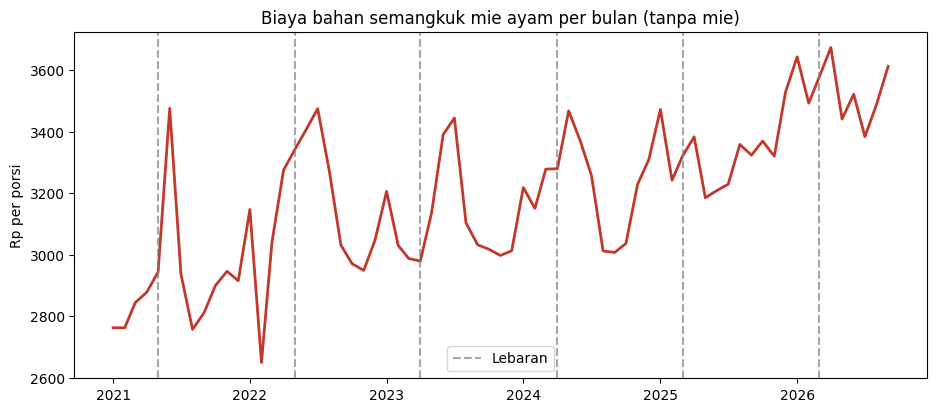

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(biaya.index, biaya["total"], color="#c0392b", lw=2)
for i, b in enumerate(lebaran_bulan):
    ax.axvline(b, color="gray", ls="--", alpha=.7, label="Lebaran" if i == 0 else None)
ax.set_title("Biaya bahan semangkuk mie ayam per bulan (tanpa mie)")
ax.set_ylabel("Rp per porsi")
ax.legend()
plt.show()

## Cek pemahaman (jawab dengan kata sendiri di sini)
1. Kenapa data harus di-*pivot* dulu sebelum dihitung?
2. Kenapa garis putus-putus pakai bulan, bukan tanggal Lebaran persis?
3. Dari grafik, apakah ada lonjakan di sekitar garis Lebaran? (tebakan dulu, dibuktikan di Bagian 2)

1. supaya format datanya *long*: satu baris per bulan per komoditas. Untuk menghitung biaya per bulan, lebih enak kalau tiap komoditas jadi satu kolom (format *wide*)
2. karena kalo tanggal lebaran persis datanya tidak akan exact dan time frame waktunya pun bisa berbeda beda tiap tahunnya
3. iya lonjakannya pasti kebanyakan sebelum garis atau mejelang menyentuh garis putus putusnya dan jarang ketika sudah melewati garis dia baru melonjak